<a href="https://colab.research.google.com/github/swabhimansahu2004/Full-Stack-Programming-Practice/blob/main/Phase_1_Data_Cleaning_and_Correlation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset loaded successfully!


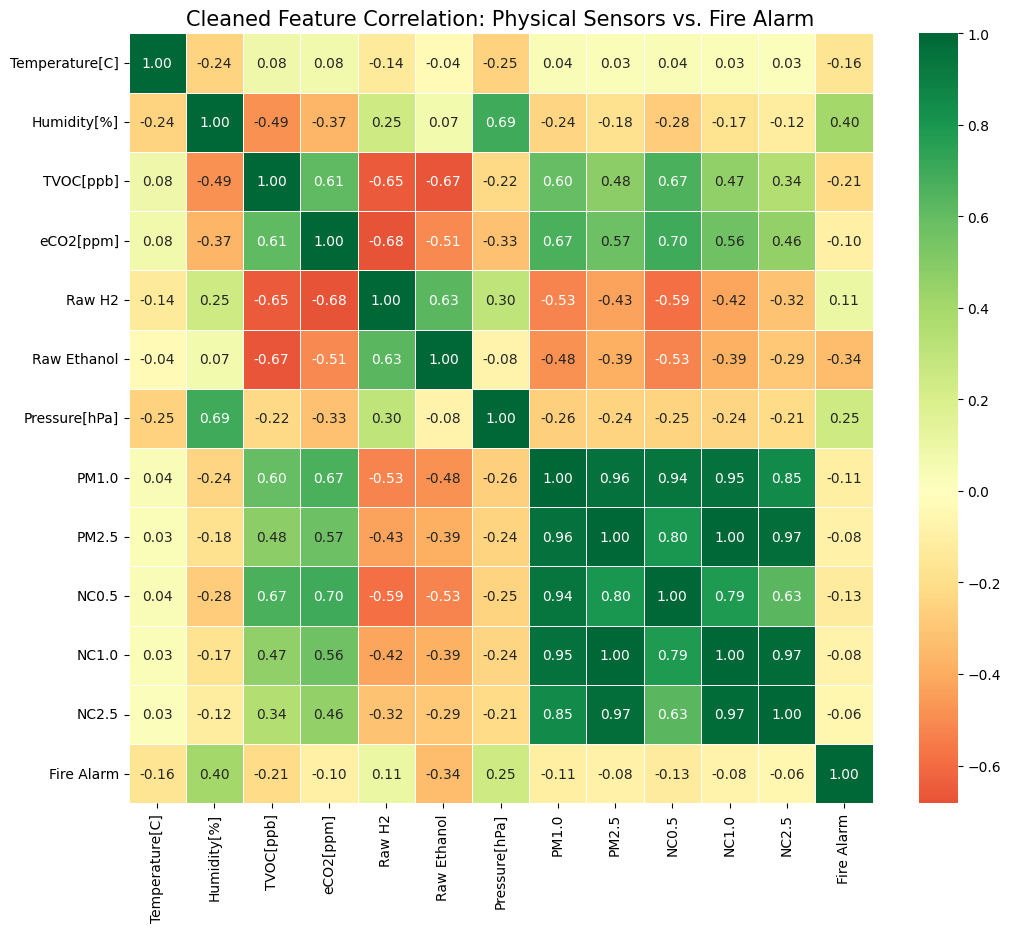


TOP PHYSICAL FEATURES CORRELATING WITH FIRE ALARM
Fire Alarm        1.000000
Humidity[%]       0.399846
Pressure[hPa]     0.249797
Raw H2            0.107007
NC2.5            -0.057707
NC1.0            -0.082828
PM2.5            -0.084916
eCO2[ppm]        -0.097006
PM1.0            -0.110552
NC0.5            -0.128118
Temperature[C]   -0.163902
TVOC[ppb]        -0.214743
Raw Ethanol      -0.340652
Name: Fire Alarm, dtype: float64

Suggested Features for Teacher Model Input:
['Humidity[%]', 'Pressure[hPa]', 'Raw H2', 'NC2.5', 'NC1.0', 'PM2.5', 'eCO2[ppm]', 'PM1.0', 'NC0.5', 'Temperature[C]', 'TVOC[ppb]', 'Raw Ethanol']


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. LOAD THE DATA
try:
    df = pd.read_csv('smoke_detection_iot.csv')
    print("Dataset loaded successfully!")
except:
    print("Error: Could not find CSV file.")

# 2. DATA CLEANING (Crucial for Research Integrity)
columns_to_drop = ['UTC', 'CNT', 'Unnamed: 0']
df_cleaned = df.drop(columns=columns_to_drop, errors='ignore')

# 3. CALCULATE CORRELATION
clean_corr = df_cleaned.corr()

# 4. VISUALIZE THE CLEANED CORRELATION MAP
plt.figure(figsize=(12, 10))
sns.heatmap(clean_corr,
            annot=True,
            cmap='RdYlGn',
            center=0,
            fmt='.2f',
            linewidths=0.5)

plt.title('Cleaned Feature Correlation: Physical Sensors vs. Fire Alarm', fontsize=15)
plt.show()

# 5. RANK THE FEATURES
print("\n" + "="*50)
print("TOP PHYSICAL FEATURES CORRELATING WITH FIRE ALARM")
print("="*50)
rankings = clean_corr['Fire Alarm'].sort_values(ascending=False)
print(rankings)

# 6. EXPORTING FOR PROPOSAL
# This creates a small table you can copy-paste into your report
print("\nSuggested Features for Teacher Model Input:")
print(rankings.index[1:].tolist()) # Excludes 'Fire Alarm' itself